In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('creditcard.csv')

np.random.seed(42)
n_samples = 1000
data = {
    'V1': np.random.normal(0, 1, n_samples),
    'V2': np.random.normal(0, 1, n_samples),
    'V3': np.random.normal(0, 1, n_samples),
    'V4': np.random.normal(0, 1, n_samples),
    'Amount': np.random.exponential(100, n_samples)
}
df = pd.DataFrame(data)

df['Class'] = np.random.choice([0, 1], size=n_samples, p=[0.98, 0.02])

X = df.drop('Class', axis=1)
y = df['Class']

# Mengubah target 0 dan 1 menjadi -1 dan 1 agar sesuai dengan visualisasi
y_mod = np.where(y == 0, -1, 1)

In [2]:
# 2. Reduksi Dimensi menggunakan PCA (Agar data multidimensi dapat divisualisasikan dalam 2D)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [3]:
model = SVC(kernel='linear', C=1.0)
model.fit(X_pca, y_mod)

# Model SVM dengan berbagai Kernel Trick
C_value = 1.0
gamma_value = 0.7

models = (
    SVC(kernel='linear', C=C_value),
    SVC(kernel='rbf', gamma=gamma_value, C=C_value),
    SVC(kernel='poly', degree=3, C=C_value),
    SVC(kernel='sigmoid', C=C_value, gamma=0.1)
)

# Melatih model
models = (clf.fit(X_pca, y) for clf in models)

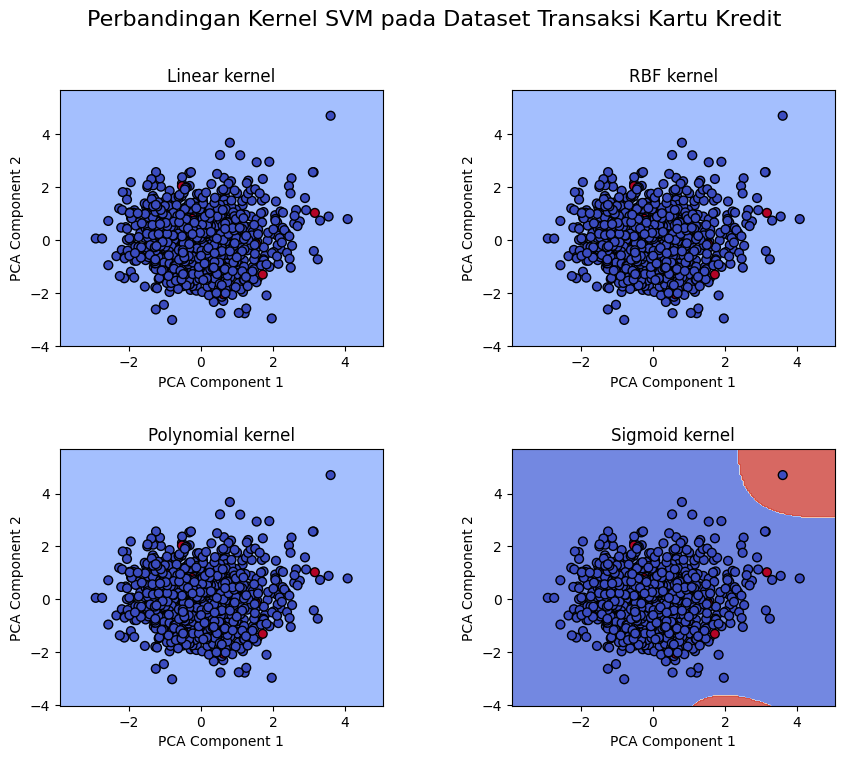

In [4]:
# Pengaturan Visualisasi
titles = (
    'Linear kernel',
    'RBF kernel',
    'Polynomial kernel',
    'Sigmoid kernel'
)

fig, sub = plt.subplots(2, 2, figsize=(10, 8))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

# Buat grid untuk batas keputusan
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

for clf, title, ax in zip(models, titles, sub.flatten()):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot kontur untuk area keputusan
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    
    # Plot titik-titik data
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=40)
    
    ax.set_title(title)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

fig.suptitle('Perbandingan Kernel SVM pada Dataset Transaksi Kartu Kredit', fontsize=16)
plt.show()

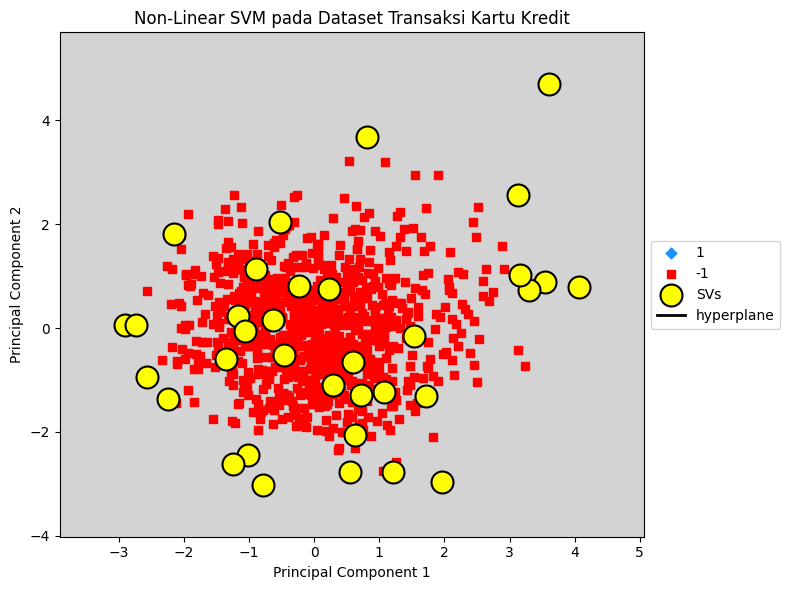

In [6]:
# 4. Pengaturan Visualisasi
plt.figure(figsize=(8, 6))

# Mengatur latar belakang abu-abu agar mirip dengan contoh gambar
plt.gca().set_facecolor('#d3d3d3')

# Plot data kelas 1 (Blue Diamond)
mask_1 = (y_mod == 1)
plt.scatter(X_pca[mask_1, 0], X_pca[mask_1, 1], color='dodgerblue', marker='D', label='1', s=30, zorder=3)

# Plot data kelas -1 (Red Square)
mask_minus_1 = (y_mod == -1)
plt.scatter(X_pca[mask_minus_1, 0], X_pca[mask_minus_1, 1], color='red', marker='s', label='-1', s=30, zorder=3)

# Plot Support Vectors (SVs)
# Diberi lingkaran kuning dengan pinggiran hitam
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=250, facecolors='yellow', edgecolors='black', 
            linewidth=1.5, marker='o', label='SVs', zorder=4)

# Menghitung dan menggambar garis Hyperplane
# Persamaan garis: w[0]*X1 + w[1]*X2 + b = 0 -> X2 = (-w[0]*X1 - b) / w[1]
w = model.coef_[0]
b = model.intercept_[0]

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 100)
y_line = -(w[0] * x_line + b) / w[1]

plt.plot(x_line, y_line, color='black', linewidth=2, label='hyperplane', zorder=2)

# Batas sumbu grafik menyesuaikan PCA
plt.xlim(x_min, x_max)
plt.ylim(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1)

# Label dan Judul
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Non-Linear SVM pada Dataset Transaksi Kartu Kredit')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(False)

plt.tight_layout()
plt.show()